# Подготовил Липатов Данила МСМТ 243

# Задача 1. Рост сети цитирований

Анализируем датасет HepPh.

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from scipy.optimize import curve_fit
from collections import Counter
import powerlaw
%matplotlib inline


In [5]:
# !pip3 install gdown

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for gdown from https://files.pythonhosted.org/packages/87/21/35dd0a0b7428bd67b12b358d7b4277f693493a3839b071d540a4c8357b78/gdown-5.2.1-py3-none-any.whl.metadata
  Obtaining dependency information for beautifulsoup4 from https://files.pythonhosted.org/packages/1a/39/47f9197bdd44df24d67ac8893641e16f386c984a0619ef2ee4c51fbbc019/beautifulsoup4-4.14.3-py3-none-any.whl.metadata
  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
  Obtaining dependency information for filelock from https://files.pythonhosted.org/packages/9c/0f/5d0c71a1aefeb08efff26272149e07ab922b64f46c63363756224bd6872e/filelock-3.24.3-py3-none-any.whl.metadata
  Obtaining dependency information for requests[socks] from https://files.pythonhosted.org/packages/1e/db/4254e3eabe8020b458f1a747140d32277ec7a271daf1d235b70dc0b4e6e3/requests-2.32.5-py3-none-any.whl.metadata
  Using cached requests-2.32.5

In [34]:

# import os
# if not os.path.exists('Cit-HepPh.txt'):
#     !gdown 1vIbbqxDx7Y1nYfE8pAx-eLtbhSokSu6V
# if not os.path.exists('cit-HepPh-dates.txt'):
#     !gdown 1G4SOy6ltn_gwiSOCUiZ5ZBrEeA0p0y77

import os
import gdown

if not os.path.exists('Cit-HepPh.txt'):
    gdown.download('https://drive.google.com/uc?id=1vIbbqxDx7Y1nYfE8pAx-eLtbhSokSu6V', 'Cit-HepPh.txt', quiet=False)

if not os.path.exists('cit-HepPh-dates.txt'):
    gdown.download('https://drive.google.com/uc?id=1G4SOy6ltn_gwiSOCUiZ5ZBrEeA0p0y77', 'cit-HepPh-dates.txt', quiet=False)
    

In [131]:
# (цитирование возможно только когда оба узла существуют, тогда нужен ориентированный граф)
G = nx.read_edgelist('Cit-HepPh.txt', nodetype=int, create_using=nx.DiGraph())
print('Nodes:', G.number_of_nodes())
print('Edges:', G.number_of_edges())
print('Density:', nx.density(G))

data = pd.read_csv('cit-HepPh-dates.txt', sep='\t', header=None, names=['node', 'date'], comment='#')
data['date'] = pd.to_datetime(data['date'])

data['month'] = data['date'].dt.to_period('M')
data = data[data['node'].isin(G.nodes())].copy()
data = data.set_index('node')

print(data.head())
print('Количество уникальных месяцев:', data['month'].nunique())

Nodes: 34546
Edges: 421578
Density: 0.00035326041393102855
              date    month
node                       
9203201 1992-02-24  1992-02
9203202 1992-03-08  1992-03
9203203 1992-03-03  1992-03
9203206 1992-03-09  1992-03
9203207 1992-03-10  1992-03
Количество уникальных месяцев: 122


## Подзадача 1: Рост степени «старых» вершин со временем

Выбираем несколько вершин, появившихся в самом начале, и смотрим как растёт их степень (число входящих цитирований) с каждым новым месяцем. Важно отметит, что граф должен быть ориентированным и тогда плотность у наас будет равна ρ=E / N(N−1) вместо 2E / N(N-1). Идея такая, что 
ребро (A -> B) означает "статья A цитирует статью B":
статья B уже существует
статья A только что появилась

In [36]:
# Сортируем месяцы
sorted_months = sorted(data['month'].unique())


# first_month = sorted_months[0]
# old_nodes = data[data['month'] == first_month].index.tolist()

# для наглядного степенного закона, иначе не совсем корректный вывод
early_months = sorted_months[:3]  # первые 3 месяца
old_nodes = data[data['month'].isin(early_months)].index.tolist()

print(f'Вершины из первого месяца ({first_month}): {len(old_nodes)}')

# Для наглядности возьмём самые «популярные»
old_nodes_by_degree = sorted(old_nodes, key=lambda n: G.in_degree(n), reverse=True)
# selected_nodes = old_nodes_by_degree[:5]

selected_nodes = [n for n in old_nodes_by_degree if G.in_degree(n) > 50][:5]
print(f'Выбранные вершины и их итоговая степень: {[(n, G.in_degree(n)) for n in selected_nodes]}')

Вершины из первого месяца (1992-02): 56
Выбранные вершины и их итоговая степень: [(9203203, 217), (9203223, 127), (9204225, 102), (9204214, 98), (9204211, 84)]



**Для каждого ребра определяем, в какой месяц оно «появилось» \
Ребро (u->v) появляется в месяц max(month_u, month_v)**


In [39]:
degree_over_time = {n: [] for n in selected_nodes}
time_axis = []

# Оставляем только вершины, которые есть в графе
selected_nodes = [n for n in selected_nodes if n in G.nodes()]

for t_idx, t in enumerate(sorted_months):
    active_nodes = set(n for n, m in node_to_month.items() if m <= t)
    subgraph = G.subgraph(active_nodes)
    
    time_axis.append(t_idx + 1)
    for n in selected_nodes:
        if n in subgraph:
            # правильный способ получить число — взять второй элемент из (node, degree)
            deg = dict(subgraph.in_degree())[n]
        else:
            deg = 0
        degree_over_time[n].append(deg)

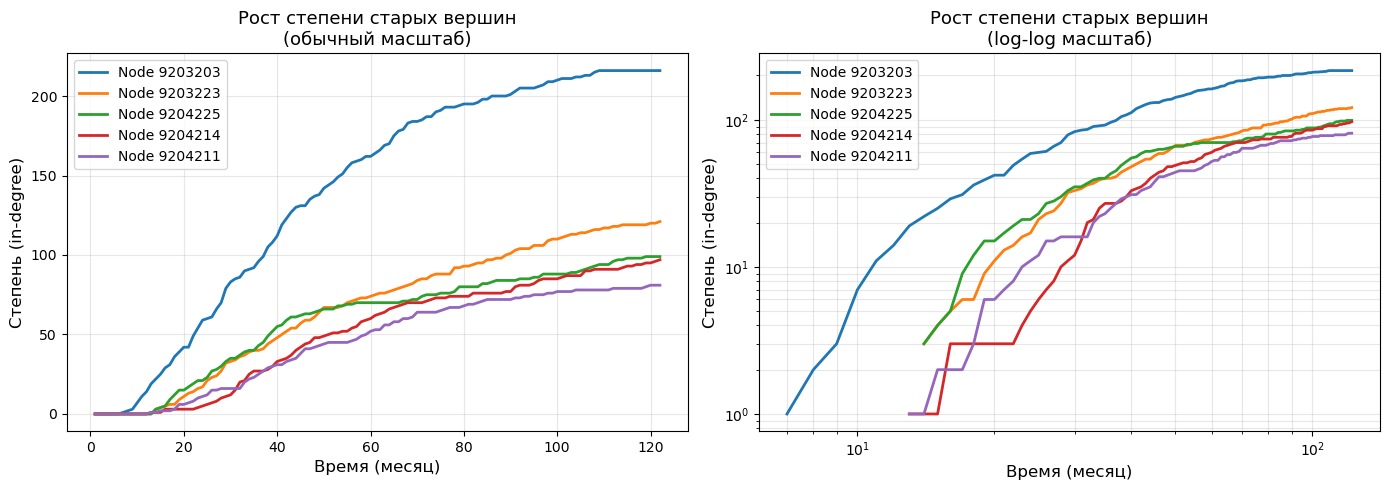

In [42]:
# График 1: Рост степени в обычном масштабе
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for n in selected_nodes:
    axes[0].plot(time_axis, degree_over_time[n], label=f'Node {n}', lw=2)

axes[0].set_xlabel('Время (месяц)', fontsize=12)
axes[0].set_ylabel('Степень (in-degree)', fontsize=12)
axes[0].set_title('Рост степени старых вершин\n(обычный масштаб)', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: Тот же график в log-log масштабе — проверяем степенной закон
for n in selected_nodes:
    y = degree_over_time[n]
    # Берём только ненулевые значения
    x_log = [time_axis[i] for i in range(len(y)) if y[i] > 0]
    y_log = [y[i] for i in range(len(y)) if y[i] > 0]
    axes[1].plot(x_log, y_log, label=f'Node {n}', lw=2)

axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Время (месяц)', fontsize=12)
axes[1].set_ylabel('Степень (in-degree)', fontsize=12)
axes[1].set_title('Рост степени старых вершин\n(log-log масштаб)', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('plot1_degree_growth.png', dpi=150, bbox_inches='tight')
plt.show()


Синяя кривая (9203203) выглядит почти как прямая линия в log-log — это признак степенного закона k(t)∼tβ \
Остальные кривые немного ступенчатые в начале (мало цитирований в первые месяцы), но потом тоже выпрямляются.

In [130]:
n_example = selected_nodes[0]
y = degree_over_time[n_example]

x_log = np.array([time_axis[i] for i in range(len(y)) if y[i] > 10 and time_axis[i] > 20])
y_log = np.array([y[i] for i in range(len(y)) if y[i] > 10 and time_axis[i] > 20])

coeffs = np.polyfit(np.log(x_log), np.log(y_log), 1)
beta = coeffs[0]
print(f'Показатель β ≈ {beta:.3f}')
print(f'Ожидаемое теоретическое значение для линейного: β = 0.5')

Показатель β ≈ 0.799
Ожидаемое теоретическое значение для линейного: β = 0.5


Для вершины 9203203 был получен показатель степенного роста β ≈ 0.8. Теоретическое значение для модели Барабаши-Альберт составляет β = 0.5, наше значение несколько выше. Отклонение можно объяснить тем, что реальная сеть цитирований неоднородна — некоторые статьи получают непропорционально много ссылок, что ускоряет рост степени отдельных вершин по сравнению с идеальной моделью.

## Подзадача 2: Прирост степени Δk и кумулятивное распределение π(k)

Для каждой вершины считаем, сколько новых цитирований она получила за месяц, и группируем по степени  \
Для каждого ребра (u, v) определяем месяц его появления \
Ребро появляется в тот месяц, когда оба узла уже существуют \
Поскольку это граф цитирований (u цитирует v), ребро появляется в month(u)

In [67]:
from collections import defaultdict

edge_months = []
for u, v in G.edges():
    if u in node_to_month and v in node_to_month:
        edge_months.append((node_to_month[u], v))

print(f'Рёбер с известными датами: {len(edge_months)}')

delta_k_by_month = defaultdict(lambda: defaultdict(int))
for month, v in edge_months:
    delta_k_by_month[month][v] += 1

Рёбер с известными датами: 347268


In [75]:
cumulative_degree = defaultdict(int)
first_month_data = sorted_months[0]
for v in G.nodes():
    if v in node_to_month and node_to_month[v] < first_month_data:
        cumulative_degree[v] = G.in_degree(v)

pi_k = defaultdict(float)
count_k = defaultdict(int)

for t in sorted_months:
    if t not in delta_k_by_month:
        continue
    for v, dk in delta_k_by_month[t].items():
        k = cumulative_degree[v]  # степень в НАЧАЛЕ месяца
        pi_k[k] += dk
        count_k[k] += 1
        cumulative_degree[v] += dk

pi_k_normalized = {k: pi_k[k] / count_k[k] 
                   for k in pi_k if count_k[k] > 0 and k > 0}

k_values = np.array(sorted(pi_k_normalized.keys()))
pi_values = np.array([pi_k_normalized[k] for k in k_values])

print(f'Число уникальных значений степени k: {len(k_values)}')
print(f'Диапазон k: от {k_values.min()} до {k_values.max()}')


Число уникальных значений степени k: 460
Диапазон k: от 1 до 655


## Подзадача 3: Зависимость π(k)

Показатель α = 0.325
α < 1 → сублинейное присоединение


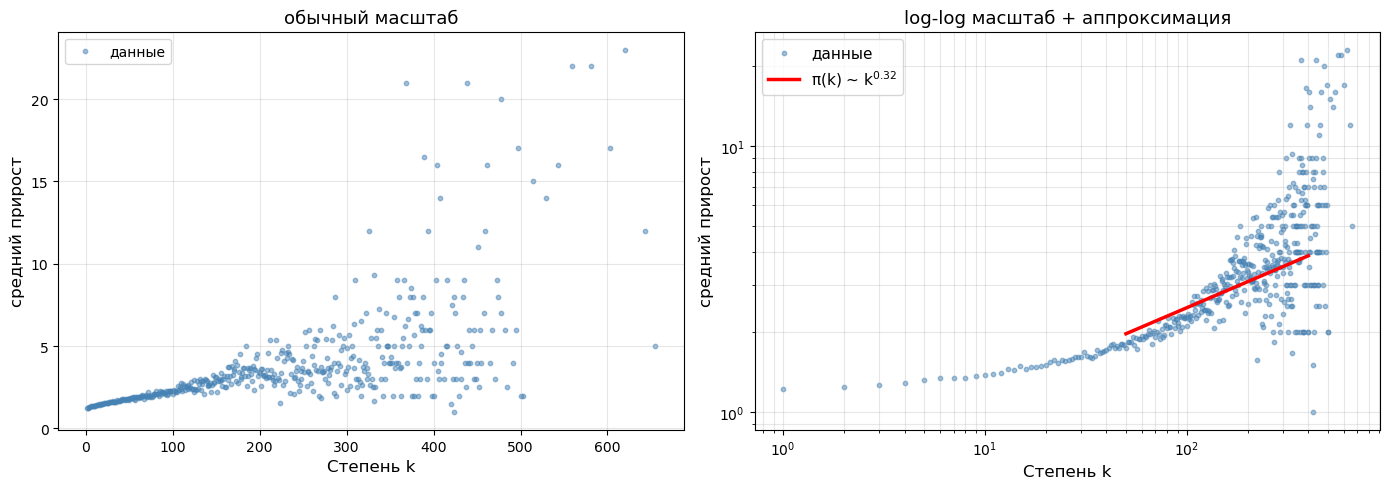

In [72]:
mask = (k_values >= 5) & (k_values <= 200)
log_k = np.log(k_values[mask])
log_pi = np.log(pi_values[mask])
coeffs = np.polyfit(log_k, log_pi, 1)
alpha = coeffs[0]
C = coeffs[1]

print(f'Показатель α = {alpha:.3f}')
if abs(alpha - 1.0) < 0.2:
    print('α ≈ 1 → линейное предпочтительное присоединение (BA-модель)')
elif alpha < 1:
    print('α < 1 → сублинейное присоединение')
else:
    print('α > 1 → суперлинейное присоединение')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(k_values, pi_values, s=10, alpha=0.5, color='steelblue', label='данные')
axes[0].set_xlabel('Степень k', fontsize=12)
axes[0].set_ylabel('средний прирост', fontsize=12)
axes[0].set_title('обычный масштаб', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

k_line = np.logspace(np.log10(50), np.log10(400), 200)
pi_line = np.exp(C) * k_line**alpha

axes[1].scatter(k_values, pi_values, s=10, alpha=0.5, color='steelblue', label='данные')
axes[1].plot(k_line, pi_line, 'r-', lw=2.5, label=f'π(k) ~ k$^{{{alpha:.2f}}}$')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Степень k', fontsize=12)
axes[1].set_ylabel('средний прирост', fontsize=12)
axes[1].set_title('log-log масштаб + аппроксимация', fontsize=13)
axes[1].grid(True, alpha=0.3, which='both')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

Сузим диапазон:

Показатель α = 0.506
α < 1 → сублинейное присоединение


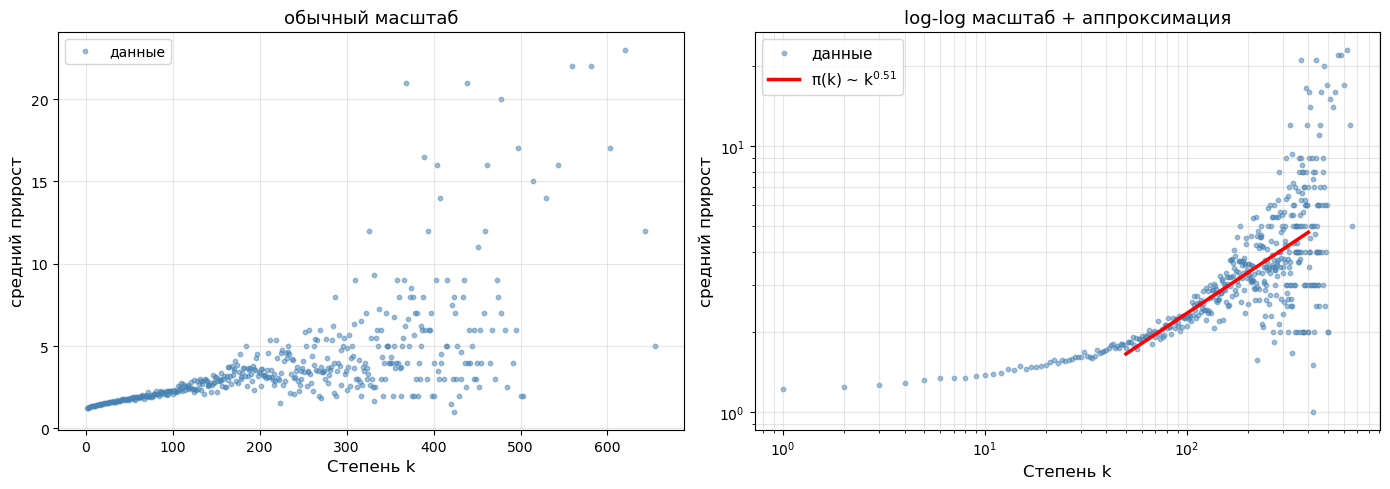

In [73]:
mask = (k_values >= 50) & (k_values <= 400)
log_k = np.log(k_values[mask])
log_pi = np.log(pi_values[mask])
coeffs = np.polyfit(log_k, log_pi, 1)
alpha = coeffs[0]
C = coeffs[1]

print(f'Показатель α = {alpha:.3f}')
if abs(alpha - 1.0) < 0.2:
    print('α ≈ 1 → линейное предпочтительное присоединение (BA-модель)')
elif alpha < 1:
    print('α < 1 → сублинейное присоединение')
else:
    print('α > 1 → суперлинейное присоединение')


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].scatter(k_values, pi_values, s=10, alpha=0.5, color='steelblue', label='данные')
axes[0].set_xlabel('Степень k', fontsize=12)
axes[0].set_ylabel('средний прирост', fontsize=12)
axes[0].set_title('обычный масштаб', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

k_line = np.logspace(np.log10(50), np.log10(400), 200)
pi_line = np.exp(C) * k_line**alpha

axes[1].scatter(k_values, pi_values, s=10, alpha=0.5, color='steelblue', label='данные')
axes[1].plot(k_line, pi_line, 'r-', lw=2.5, label=f'π(k) ~ k$^{{{alpha:.2f}}}$')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Степень k', fontsize=12)
axes[1].set_ylabel('средний прирост', fontsize=12)
axes[1].set_title('log-log масштаб + аппроксимация', fontsize=13)
axes[1].grid(True, alpha=0.3, which='both')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

Показатель α ≈ 0.51 < 1 — сублинейное предпочтительное присоединение. \
Вероятность получить новое цитирование растёт с числом уже имеющихся,
но медленнее, чем предсказывает линейная модель Барабаши–Альберт (α = 1).

## Задание 2. Нелинейное предпочтительное присоединение

In [78]:
# pip install powerlaw 

### Часть 1: Генератор графа с нелинейным предпочтительным присоединением

In [85]:
def nonlinear_pa_graph(n, m, alpha, seed=7):
    rng = np.random.default_rng(seed)
    
    # Инициализация: затравочный граф — полный граф на m вершинах
    G = nx.complete_graph(m)
    
    degrees = dict(G.degree())

    degree_history = [degrees[0]]
    
    nodes = list(G.nodes())
    
    for new_node in range(m + 1, n):
        k_arr = np.array([max(degrees[v], 1e-9) for v in nodes])
        weights = k_arr ** alpha
        probs = weights / weights.sum()
        
        # targets = rng.choice(nodes, size=m, replace=False, p=probs)
        chosen = set()
        while len(chosen) < m:
            idx = rng.choice(len(nodes), p=probs)
            chosen.add(idx)
        targets = [nodes[i] for i in chosen]
        
        G.add_node(new_node)
        degrees[new_node] = 0
        
        for t in targets:
            G.add_edge(new_node, t)
            degrees[new_node] += 1
            degrees[t] += 1
        
        nodes.append(new_node)
        # degree_history.append(degrees[0])
        degree_history.append(max(degrees.values()))
    return G, degree_history


### Часть 2: Рост степени затравочной вершины для α = 0.5, 1.0, 2.5

alpha=0.5
alpha=1.0
alpha=2.5


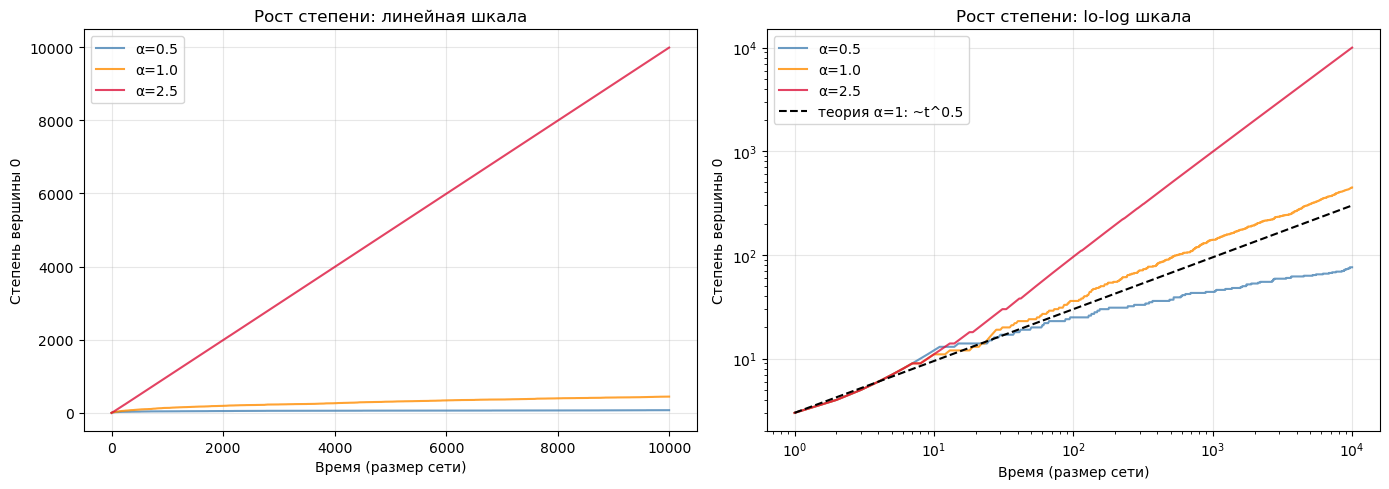

In [129]:
m = 4
n_max = 10_000
alphas = [0.5, 1.0, 2.5]
colors = ['steelblue', 'darkorange', 'crimson']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results = {}

for alpha, color in zip(alphas, colors):
    print(f'alpha={alpha}')
    G, hist = nonlinear_pa_graph(n_max, m, alpha, seed=756)
    results[alpha] = G
    
    t = np.arange(len(hist))
    
    axes[0].plot(t, hist, color=color, alpha=0.8, label=f'α={alpha}')

    axes[1].loglog(t + 1, hist, color=color, alpha=0.8, label=f'α={alpha}')

# Теоретическая кривая для α=1: k(t) ~ t^0.5 (Барабаши Альберт)
t_theory = np.linspace(1, n_max, 500)
k0_theory = hist[0]
axes[1].loglog(t_theory, k0_theory * (t_theory / 1) ** 0.5,
               'k--', linewidth=1.5, label='теория α=1: ~t^0.5')

for ax in axes:
    ax.set_xlabel('Время (размер сети)')
    ax.set_ylabel('Степень вершины 0')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[0].set_title('Рост степени: линейная шкала')
axes[1].set_title('Рост степени: lo-log шкала')

plt.tight_layout()
plt.show()

### Часть 3: Распределение степеней и аппроксимация через powerlaw

α=0.5: γ=2.868, xmin=4.0, log-ratio(power_law vs exp)=887.735 (p=0.000)
α=1.0: γ=3.000, xmin=4.0, log-ratio(power_law vs exp)=3069.752 (p=0.000)
α=2.5: γ=3.000, xmin=4.0, log-ratio(power_law vs exp)=-47382.138 (p=0.000)


/opt/anaconda3/envs/catboost_env/lib/python3.13/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,
/opt/anaconda3/envs/catboost_env/lib/python3.13/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


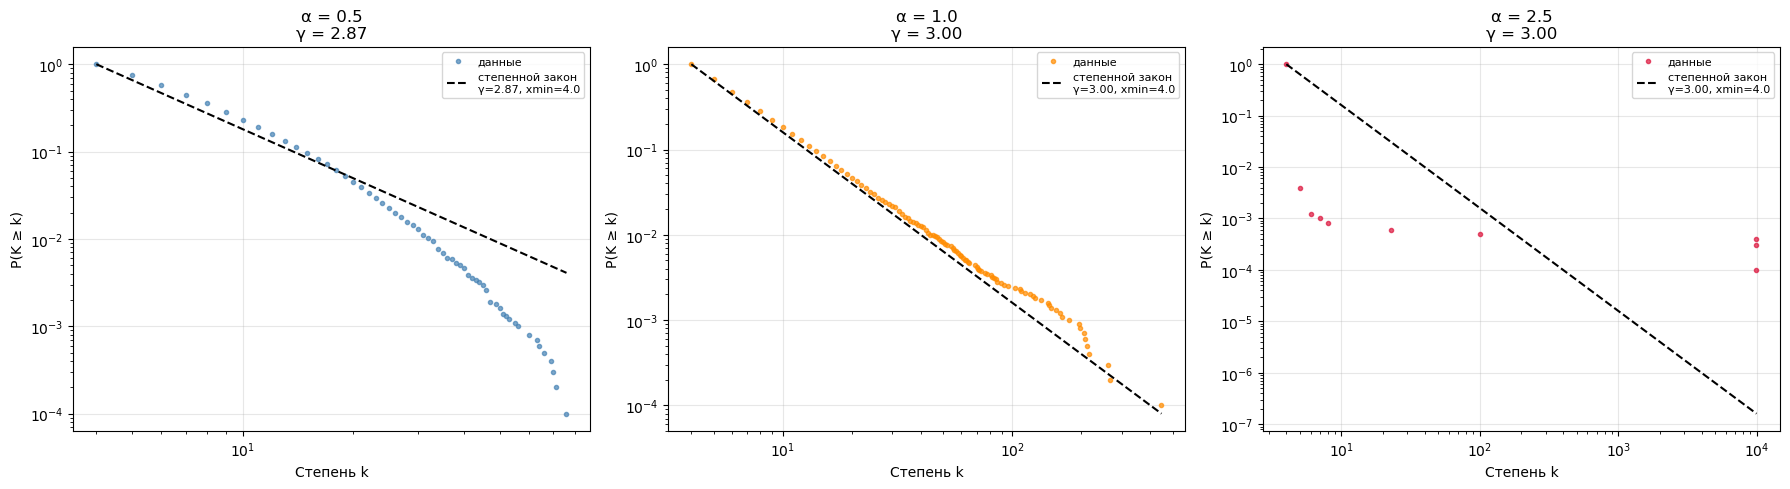

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (alpha, color) in zip(axes, zip(alphas, colors)):
    G = results[alpha]

    degree_sequence = sorted([d for _, d in G.degree()], reverse=True)

    degree_count = Counter(degree_sequence)
    deg, cnt = zip(*sorted(degree_count.items()))
    deg = np.array(deg)
    cnt = np.array(cnt)
    prob = cnt / cnt.sum()

    ccdf = np.cumsum(prob[::-1])[::-1]
    ax.loglog(deg, ccdf, 'o', color=color, markersize=3, alpha=0.7, label='данные')
    
    # Аппроксимация через powerlaw
    # fit = powerlaw.Fit(degree_sequence, verbose=False)
    fit = powerlaw.Fit(degree_sequence, xmin=4, verbose=False)
    gamma = fit.power_law.alpha
    xmin = fit.power_law.xmin
    
    fit.power_law.plot_ccdf(ax=ax, color='black', linestyle='--',
                             label=f'степенной закон\nγ={gamma:.2f}, xmin={xmin}')

    R, p = fit.distribution_compare('power_law', 'exponential')
    print(f'α={alpha}: γ={gamma:.3f}, xmin={xmin}, '
          f'log-ratio(power_law vs exp)={R:.3f} (p={p:.3f})')
    
    ax.set_xlabel('Степень k')
    ax.set_ylabel('P(K ≥ k)')
    ax.set_title(f'α = {alpha}\nγ = {gamma:.2f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

При α = 0.5 степенной закон формально лучше экспоненты, но на графике видно что точки в хвосте уходят вниз и не следуют за пунктирной линией. То есть аппроксимация не очень хорошая — распределение не совсем степенное

При α = 1.0 всё красиво — точки хорошо ложатся на пунктирную линию, γ ≈ 3.0, что совпадает с теорией

При α = 2.5 аппроксимировать вообще нечего — на графике буквально несколько точек. Почти все вершины имеют маленькую степень. Никакого нормального распределения нет, степенной закон здесь просто не работает.

## Задание 3. Модели предпочтительного присоединения направленной сети

### Часть 1: Генератор направленной сети с постоянной привлекательностью A

In [99]:
def directed_pa_graph(n, m, A, seed=42):
    rng = np.random.default_rng(seed)

    G = nx.DiGraph()
    
    # Затравка: полный граф на m вершинах
    for i in range(m):
        G.add_node(i)
    for i in range(m):
        for j in range(m):
            if i != j:
                G.add_edge(i, j)
    
    k_in = {i: G.in_degree(i) for i in range(m)}
    nodes = list(range(m))
    
    for new_node in range(m, n):
        G.add_node(new_node)
        k_in[new_node] = 0
        
        # (A + k_in) / sum(A + k_in)
        weights = np.array([A + k_in[v] for v in nodes], dtype=float)
        probs = weights / weights.sum()
        
        chosen = set()
        while len(chosen) < m:
            idx = rng.choice(len(nodes), p=probs)
            chosen.add(idx)
        
        for idx in chosen:
            target = nodes[idx]
            G.add_edge(new_node, target)  # ребро ОТ новой вершины К выбранной
            k_in[target] += 1
        
        nodes.append(new_node)
    
    return G


def bidirectional_fraction(G):
    bidir_pairs = 0
    total_pairs = 0
    checked = set()
    for u, v in G.edges():
        if (v, u) not in checked:
            total_pairs += 1
            checked.add((u, v))
            if G.has_edge(v, u):
                bidir_pairs += 1
    return bidir_pairs / total_pairs if total_pairs > 0 else 0


A=  1: γ=1.95, mean=5.0, std=33.9, max=656, bidir=0.001
A= 10: γ=2.46, mean=5.0, std=8.7, max=104, bidir=0.001
A=100: γ=2.67, mean=5.0, std=5.7, max=42, bidir=0.001


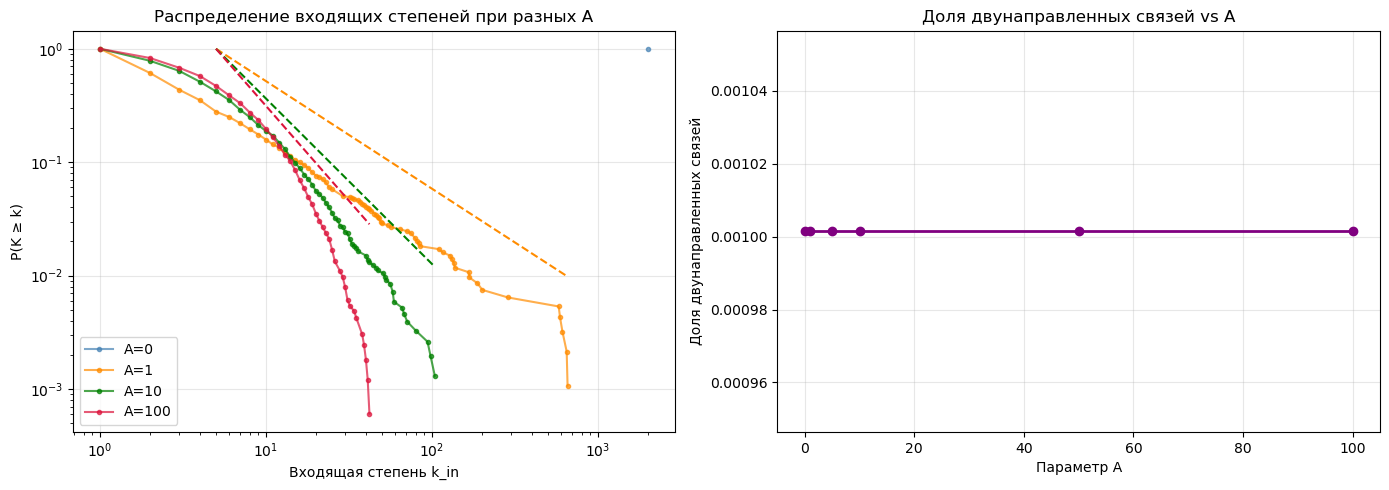

In [113]:
n = 2000

m = 5
A_values = [0, 1, 10, 100]
colors = ['steelblue', 'darkorange', 'green', 'crimson']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stats_table = []

for A, color in zip(A_values, colors):
    G = directed_pa_graph(n, m, A)
    in_degrees = [d for _, d in G.in_degree()]
    in_degrees_nonzero = [d for d in in_degrees if d > 0]
    
    stats_table.append({
        'A': A,
        'mean': np.mean(in_degrees),
        'std': np.std(in_degrees),
        'max': np.max(in_degrees),
        'min': np.min(in_degrees),
        'bidir': bidirectional_fraction(G)
    })
    
    cnt = Counter(in_degrees_nonzero)
    deg, c = zip(*sorted(cnt.items()))
    deg = np.array(deg)
    prob = np.array(c) / sum(c)
    ccdf = np.cumsum(prob[::-1])[::-1]
    
    axes[0].loglog(deg, ccdf, 'o-', color=color, markersize=3, alpha=0.7, label=f'A={A}')
    
    # Аппроксимация
    if len(in_degrees_nonzero) > 10:
        fit = powerlaw.Fit(in_degrees_nonzero, xmin=m, verbose=False)
        gamma = fit.power_law.alpha
        fit.power_law.plot_ccdf(ax=axes[0], color=color, linestyle='--', linewidth=1.5)
        print(f'A={A:3d}: γ={gamma:.2f}, mean={np.mean(in_degrees):.1f}, '
              f'std={np.std(in_degrees):.1f}, max={np.max(in_degrees)}, '
              f'bidir={bidirectional_fraction(G):.3f}')

axes[0].set_xlabel('Входящая степень k_in')
axes[0].set_ylabel('P(K ≥ k)')
axes[0].set_title('Распределение входящих степеней при разных A')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

A_range = [0, 1, 5, 10, 50, 100]
bidir_fractions = []
for A in A_range:
    G = directed_pa_graph(n, m, A)
    bidir_fractions.append(bidirectional_fraction(G))

axes[1].plot(A_range, bidir_fractions, 'o-', color='purple', linewidth=2)
axes[1].set_xlabel('Параметр A')
axes[1].set_ylabel('Доля двунаправленных связей')
axes[1].set_title('Доля двунаправленных связей vs A')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Доля двунаправленных связей очень мала (≈0) и практически не зависит от параметра A. Это объясняется самой структурой модели: каждая новая вершина только ссылается на существующие, но не получает ссылок обратно от них.

### Часть 2: Добавляем удаление вершин с коэффициентом r

In [114]:
def directed_pa_graph_with_removal(n_target, m, A, r, seed=42):
    rng = np.random.default_rng(seed)
    
    G = nx.DiGraph()
    for i in range(m):
        G.add_node(i)
    for i in range(m):
        for j in range(m):
            if i != j:
                G.add_edge(i, j)
    
    k_in = {i: G.in_degree(i) for i in range(m)}
    node_counter = m
    
    steps = 0
    while G.number_of_nodes() < n_target and steps < n_target * 10:
        steps += 1
        nodes = list(G.nodes())
        if len(nodes) < m:
            # слишком мало вершин, просто добавляем
            G.add_node(node_counter)
            k_in[node_counter] = 0
            node_counter += 1
            continue
        
        # Добавляем новую вершину
        new_node = node_counter
        node_counter += 1
        G.add_node(new_node)
        k_in[new_node] = 0
        
        weights = np.array([A + k_in.get(v, 0) for v in nodes], dtype=float)
        probs = weights / weights.sum()
        
        chosen = set()
        while len(chosen) < min(m, len(nodes)):
            idx = rng.choice(len(nodes), p=probs)
            chosen.add(idx)
        
        for idx in chosen:
            target = nodes[idx]
            G.add_edge(new_node, target)
            k_in[target] = k_in.get(target, 0) + 1
        
        # Удаляем случайную вершину с вероятностью r
        if rng.random() < r and G.number_of_nodes() > m:
            remove_node = rng.choice(list(G.nodes()))
            # Обновляем k_in соседей
            for pred in list(G.predecessors(remove_node)):
                k_in[remove_node] = max(0, k_in.get(remove_node, 0) - 1)
            for succ in list(G.successors(remove_node)):
                k_in[succ] = max(0, k_in.get(succ, 0) - 1)
            G.remove_node(remove_node)
            if remove_node in k_in:
                del k_in[remove_node]
    
    return G

r=0.1, A=1...
r=0.1, A=10...
r=0.8, A=1...
r=0.8, A=10...


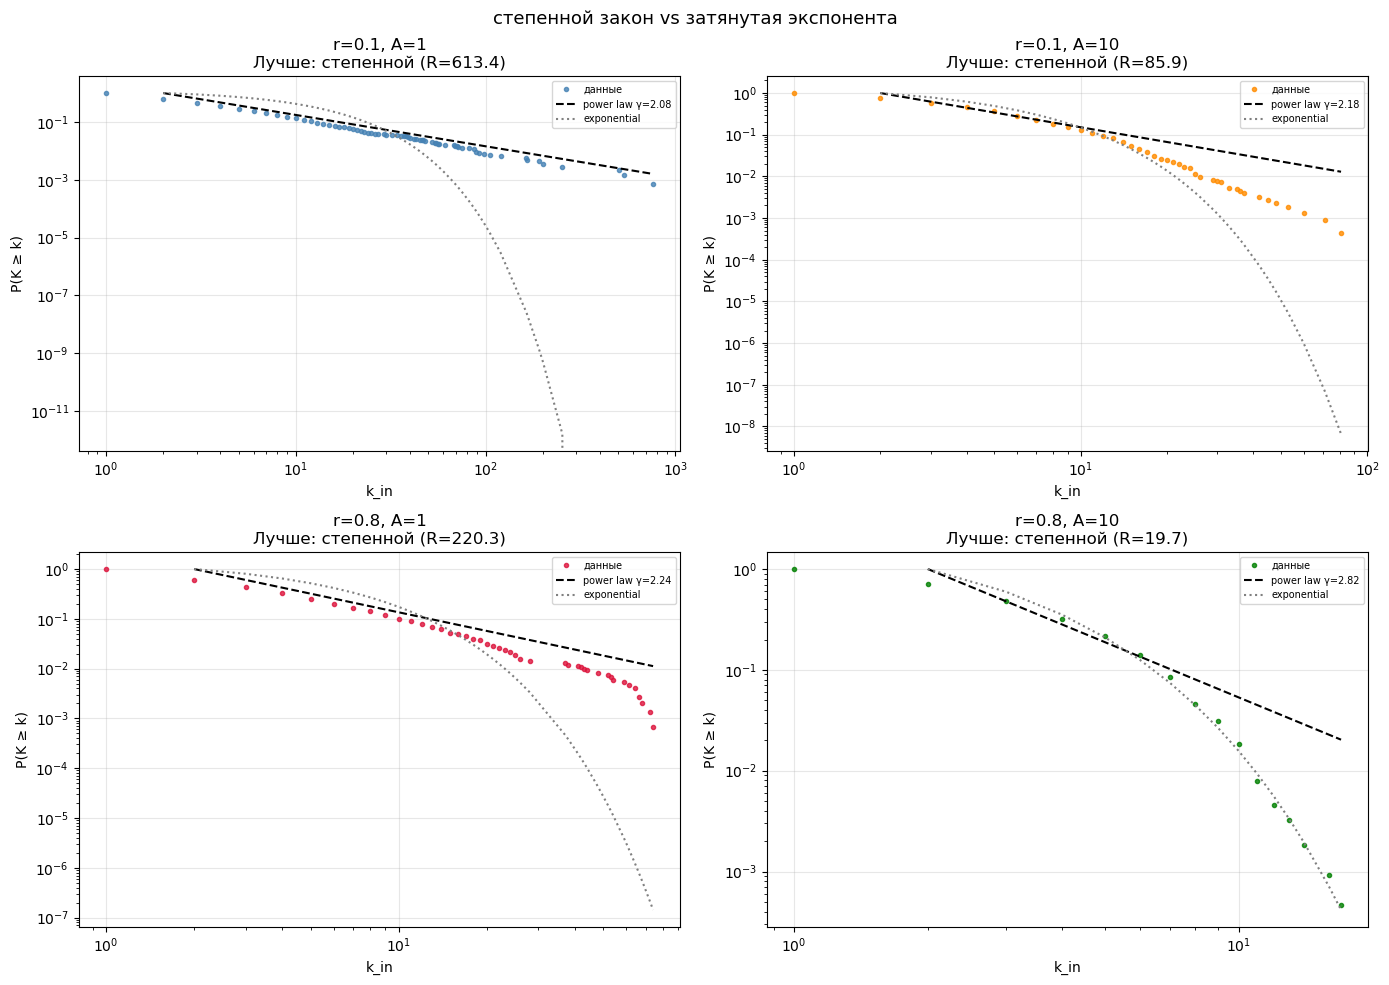

In [127]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Режим 1: малое r — степенной закон
# Режим 2: большое r — затянутая экспонента
configs = [
    (0.1, 1,   'steelblue',  'r=0.1, A=1'),
    (0.1, 10,  'darkorange', 'r=0.1, A=10'),
    (0.8, 1,   'crimson',    'r=0.8, A=1'),
    (0.8, 10,  'green',      'r=0.8, A=10'),
]

for ax, (r, A, color, label) in zip(axes.flat, configs):
    print(f'{label}...')
    G = directed_pa_graph_with_removal(3000, m=4, A=A, r=r)
    
    in_deg = [d for _, d in G.in_degree() if d > 0]
    if len(in_deg) < 10:
        ax.set_title(f'{label}(граф вырожден)')
        continue
    
    cnt = Counter(in_deg)
    deg, c = zip(*sorted(cnt.items()))
    prob = np.array(c) / sum(c)
    ccdf = np.cumsum(prob[::-1])[::-1]
    
    ax.loglog(np.array(deg), ccdf, 'o', color=color, markersize=3, alpha=0.8, label='данные')
    
    fit = powerlaw.Fit(in_deg, xmin=2, verbose=False)
    fit.power_law.plot_ccdf(ax=ax, color='black', linestyle='--', label=f'power law γ={fit.power_law.alpha:.2f}')
    fit.exponential.plot_ccdf(ax=ax, color='gray', linestyle=':', label='exponential')
    
    R, p = fit.distribution_compare('power_law', 'exponential')
    winner = 'степенной' if R > 0 else 'экспонента'
    
    ax.set_xlabel('k_in')
    ax.set_ylabel('P(K ≥ k)')
    ax.set_title(f'{label}\nЛучше: {winner} (R={R:.1f})')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('степенной закон vs затянутая экспонента', fontsize=13)
plt.tight_layout()
plt.show()

При малом r=0.1 вершины редко удаляются, хабы успевают набрать много связей — получаем степенной закон. При большом r=0.8 вершины удаляются слишком часто и хабы не успевают вырасти — хвост распределения загибается, это затянутая экспонента.

Параметр A влияет на крутизну — чем он больше, тем меньше максимальная степень и тем однороднее сеть в обоих режимах.\
P.S. powerlaw не совсем корректно будто описывает r=0.8, A=1 (нижний левый) и  r=0.8, A=10 (нижний правый) (на форумах пишут, что такое может возникуть из за данных и самого оведения в библиотеке, хотя визуально мы видим как легли наши точки)

### Часть 3: Добавляем случайное внутреннее связывание

In [126]:
def directed_pa_graph_with_rewiring(n, m, A, seed=42):
    rng = np.random.default_rng(seed)
    
    G = nx.DiGraph()
    for i in range(m):
        G.add_node(i)
    for i in range(m):
        for j in range(m):
            if i != j:
                G.add_edge(i, j)
    
    k_in = {i: G.in_degree(i) for i in range(m)}
    nodes = list(range(m))
    
    for new_node in range(m, n):
        G.add_node(new_node)
        k_in[new_node] = 0
        
        weights = np.array([A + k_in[v] for v in nodes], dtype=float)
        probs = weights / weights.sum()
        
        chosen = set()
        while len(chosen) < m:
            idx = rng.choice(len(nodes), p=probs)
            chosen.add(idx)
        
        for idx in chosen:
            target = nodes[idx]
            G.add_edge(new_node, target)
            k_in[target] += 1
        
        nodes.append(new_node)
        
        # случайно связываем m пар существующих вершин
        if len(nodes) >= 2:
            for _ in range(m):
                u, v = rng.choice(nodes, size=2, replace=False)
                if not G.has_edge(u, v):
                    G.add_edge(u, v)
                    k_in[v] += 1
    
    return G


m= 2: mean=4.0, std=7.9, max=127, min=0, bidir=0.003
m= 4: mean=7.9, std=15.5, max=234, min=0, bidir=0.007
m= 8: mean=15.8, std=30.4, max=365, min=0, bidir=0.011
m=16: mean=31.2, std=56.3, max=519, min=0, bidir=0.019


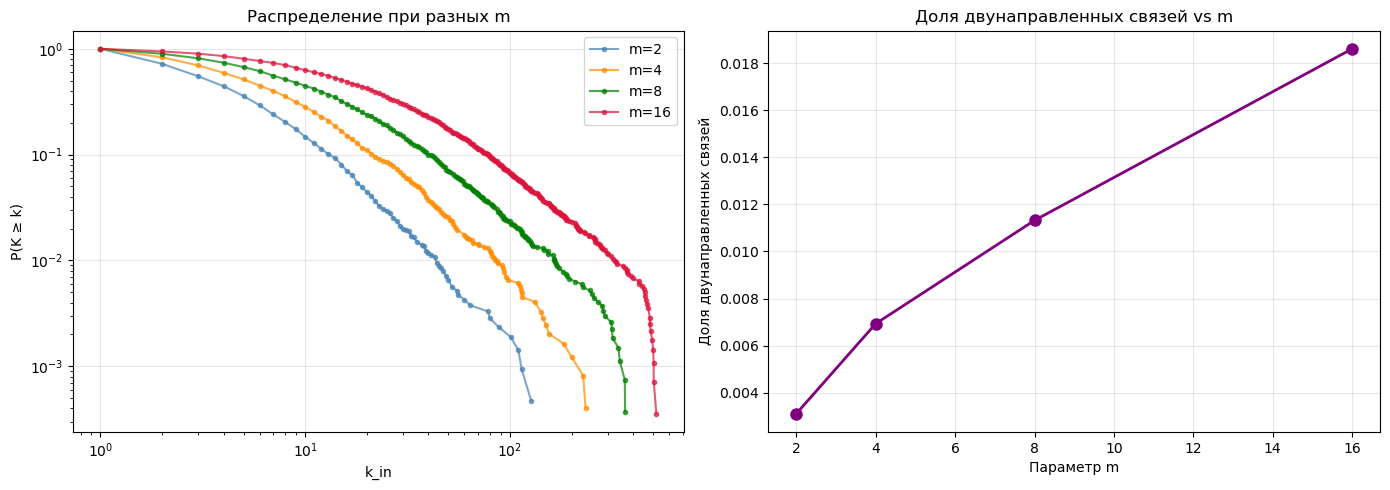

In [124]:
A = 1
m_values = [2, 4, 8, 16]
colors = ['steelblue', 'darkorange', 'green', 'crimson']
n = 3000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bidir_by_m = []

for m_val, color in zip(m_values, colors):
    G = directed_pa_graph_with_rewiring(n, m_val, A)
    
    in_deg = [d for _, d in G.in_degree() if d > 0]
    
    mean_d = np.mean([d for _, d in G.in_degree()])
    std_d = np.std([d for _, d in G.in_degree()])
    max_d = max(d for _, d in G.in_degree())
    min_d = min(d for _, d in G.in_degree())
    bidir = bidirectional_fraction(G)
    bidir_by_m.append(bidir)
    
    print(f'm={m_val:2d}: mean={mean_d:.1f}, std={std_d:.1f}, '
          f'max={max_d}, min={min_d}, bidir={bidir:.3f}')
    
    cnt = Counter(in_deg)
    deg, c = zip(*sorted(cnt.items()))
    prob = np.array(c) / sum(c)
    ccdf = np.cumsum(prob[::-1])[::-1]
    axes[0].loglog(np.array(deg), ccdf, 'o-', color=color,
                   markersize=3, alpha=0.7, label=f'm={m_val}')

axes[0].set_xlabel('k_in')
axes[0].set_ylabel('P(K ≥ k)')
axes[0].set_title('Распределение при разных m')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(m_values, bidir_by_m, 'o-', color='purple', linewidth=2, markersize=8)
axes[1].set_xlabel('Параметр m')
axes[1].set_ylabel('Доля двунаправленных связей')
axes[1].set_title('Доля двунаправленных связей vs m')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Распределение: чем больше m, тем больше среднее, разброс и максимальная степень — просто потому что на каждом шаге добавляется больше случайных рёбер. Степенного закона нет — случайные рёбра мешают хабам доминировать. \ 


Двунаправленные связи: теперь они есть и растут с m (от 0.003 до 0.019) — чем больше m, тем больше случайных пар соединяется и тем чаще два узла оказываются связаны в обе стороны. (В отличии от пункта 1)